In [3]:
import nidaqmx
import time
import numpy as np
import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE


In [5]:
data = []
times = []

nsamples = 10000
sample_time = 5
sample_freq = nsamples/sample_time

start = time.time()

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev2/ai8")
    task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE, samps_per_chan=nsamples)
    data = task.read(READ_ALL_AVAILABLE)
    
    end = time.time()
    times = np.linspace(0, end-start, len(data))

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data) + "]")

Acquired data: [1.936234, 1.933601, 1.930805, 1.928501, 1.926692, 1.925540, 1.924553, 1.923401, 1.923895, 1.924224, 1.925211, 1.925869, 1.926692, 1.928830, 1.930476, 1.932285, 1.934917, 1.936892, 1.938701, 1.940511, 1.941827, 1.943472, 1.944953, 1.945940, 1.946763, 1.946763, 1.946927, 1.947256, 1.946105, 1.944953, 1.943801, 1.942321, 1.941169, 1.938537, 1.935905, 1.933601, 1.930311, 1.927843, 1.925046, 1.922250, 1.919617, 1.917150, 1.914682, 1.912379, 1.910404, 1.909417, 1.908266, 1.907443, 1.907937, 1.908266, 1.909417, 1.910075, 1.911062, 1.913201, 1.915011, 1.916656, 1.919617, 1.921098, 1.923237, 1.925046, 1.926692, 1.928337, 1.929817, 1.931134, 1.931792, 1.931956, 1.931956, 1.931956, 1.931134, 1.930146, 1.928830, 1.927514, 1.926034, 1.923401, 1.921098, 1.918795, 1.915833, 1.913201, 1.910404, 1.907772, 1.905140, 1.902343, 1.899711, 1.897901, 1.895927, 1.894775, 1.893788, 1.893295, 1.893624, 1.894117, 1.894940, 1.895927, 1.896749, 1.898888, 1.900862, 1.902343, 1.904975, 1.906950, 1.90

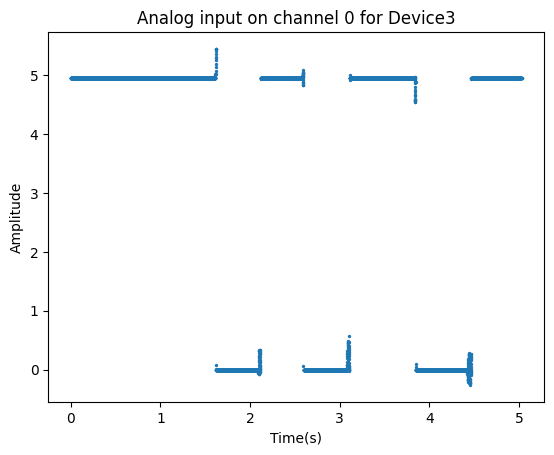

In [ ]:
plt.scatter(times, data,2)
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.title("Analog input on channel 0 for Device3")
plt.show()

In [ ]:
file = open("data.txt", "w+")
for i in range(len(data)):
    file.write(str(data[i]) + "\n")
file.close()

Later comment: I think I attached a button and measured the signal..